### Running baseline models on the Preprocessed Data

In [7]:
import torch
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split

from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer

from sklearn.ensemble import RandomForestRegressor

from sklearn.metrics import mean_squared_error, r2_score

import optuna

import os
#os.chdir('C:/GU/Thesis/code')

INPUT_DIR = 'data/preprocessed/eeg/'
SEED = 1234

In [8]:
cases_master = pd.read_csv('cases_data.csv')

ids = cases_master['caseid'].tolist()

In [9]:
# Extract and concatenate case files
dfs = []
ys = []
for id in ids:
    sample_path = os.path.join(INPUT_DIR, f'case_{id}.pt')
    sample_tensor = torch.load(sample_path)
    sample_df = pd.DataFrame(sample_tensor['features'].numpy())
    y = sample_tensor['bis'].numpy()

    valid_bis = y[y > 0]
    sample_df = sample_df[y > 0]

    sample_df['caseid'] = id
    dfs.append(sample_df)
    ys.append(valid_bis)

cases_df = pd.concat(dfs, ignore_index=True)
cases_df.rename(columns={
    0: '0', 1: '1', 2: '2', 3: '3', 4: '4', 5: '5', 6: '6', 7: '7', 8: '8', 9: '9',
    10: '10', 11: '11', 12: '12', 13: '13', 14: '14', 15: 'MBP', 16: 'HR', 17: 'SpO2',
    18: 'EtCO2'
}, inplace=True)

y = np.concatenate(ys)

In [10]:
#Find all NaN values
nan_idx = (np.isnan(y))

y = y[~nan_idx]
cases_df = cases_df.iloc[np.where(~nan_idx)[0], :]

print(len(y))

print(cases_df.shape)
print(cases_df.columns)

1879360
(1879360, 20)
Index(['0', '1', '2', '3', '4', '5', '6', '7', '8', '9', '10', '11', '12',
       '13', '14', 'MBP', 'HR', 'SpO2', 'EtCO2', 'caseid'],
      dtype='str')


In [11]:
# Concatenate patient context to each sequential second
cases_context = pd.merge(cases_master, cases_df, on='caseid', how='inner')

print(cases_context.columns)

X = cases_context.drop(columns=['caseid'])

Index(['caseid', 'optype', 'sex', 'age', 'asa', 'bmi', 'preop_hb', 'preop_k',
       'preop_na', 'preop_gluc', 'preop_cr', 'preop_alb', 'propofol',
       'volatile', 'remifentanil', '0', '1', '2', '3', '4', '5', '6', '7', '8',
       '9', '10', '11', '12', '13', '14', 'MBP', 'HR', 'SpO2', 'EtCO2'],
      dtype='str')


In [12]:
#Split into train/test data
binary_cols = ['propofol', 'volatile', 'remifentanil']
X[binary_cols] = X[binary_cols].astype(int)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.5, random_state=SEED
)

In [13]:
X_train.shape

(939680, 33)

In [15]:
categorical_cols = ['optype', 'sex', 'asa']
numerical_cols = ['age', 'bmi', 'preop_hb', 'preop_k', 'preop_na', 'preop_gluc', 'preop_cr', 'preop_alb', 
                  '0', '1', '2', '3', '4', '5' , '6', '7', '8', '9', '10', '11', '12', '13', '14',
                  'MBP', 'HR', 'SpO2', 'EtCO2' ]

preprocessor = ColumnTransformer([
    ('stdsca', StandardScaler(), numerical_cols),
    ('catenc', OneHotEncoder(handle_unknown='ignore'), categorical_cols)
])

rf = RandomForestRegressor(n_estimators=100, max_depth=10, n_jobs=-1)

pipe = Pipeline([
    ('preprocessing', preprocessor),
    ('rf', rf)
])

Stating Run for max_depth=10
Stating Run for max_depth=12
Stating Run for max_depth=14
Stating Run for max_depth=16
Stating Run for max_depth=18
Stating Run for max_depth=20


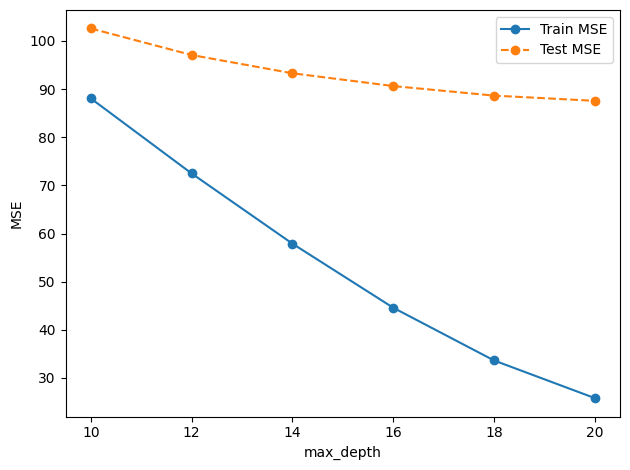

In [123]:
max_depths = [10, 12, 14, 16, 18, 20]
train_mses, test_mses = [], []

for depth in max_depths:
    print(f'Stating Run for max_depth={depth}')
    pipe.set_params(rf__max_depth=depth)
    pipe.fit(X_train, y_train)
    
    train_mses.append(mean_squared_error(y_train, pipe.predict(X_train)))
    test_mses.append(mean_squared_error(y_test,  pipe.predict(X_test)))

labels = [str(d) for d in max_depths]
plt.plot(labels, train_mses, marker='o', label='Train MSE')
plt.plot(labels, test_mses,  marker='o', label='Test MSE', linestyle='--')
plt.xlabel('max_depth')
plt.ylabel('MSE')
plt.legend()
plt.tight_layout()
plt.show()

In [126]:
from sklearn.dummy import DummyRegressor

dummy = DummyRegressor(strategy='mean')
dummy.fit(X_train, y_train)
print("Dummy MSE:", mean_squared_error(y_test, dummy.predict(X_test)))
print("RF MSE:   ", min(test_mses))

# 2. Check feature importances — is anything useful at all?
rf_fitted = pipe.named_steps['rf']
feature_names = pipe.named_steps['preprocessing'].get_feature_names_out()
importances = sorted(zip(feature_names, rf_fitted.feature_importances_), 
                     key=lambda x: -x[1])
for name, imp in importances:
    print(f"{name}: {imp:.4f}")

Dummy MSE: 237.4247589111328
RF MSE:    87.56157262458335
stdsca__EtCO2: 0.2573
stdsca__14: 0.1229
stdsca__0: 0.0701
stdsca__4: 0.0564
stdsca__13: 0.0528
stdsca__MBP: 0.0431
stdsca__10: 0.0351
stdsca__HR: 0.0283
stdsca__9: 0.0269
stdsca__3: 0.0254
stdsca__5: 0.0235
stdsca__8: 0.0210
stdsca__1: 0.0204
stdsca__age: 0.0192
stdsca__7: 0.0186
stdsca__11: 0.0177
stdsca__preop_cr: 0.0172
stdsca__2: 0.0171
stdsca__bmi: 0.0166
stdsca__12: 0.0154
stdsca__6: 0.0142
stdsca__preop_gluc: 0.0141
stdsca__preop_hb: 0.0128
stdsca__preop_k: 0.0125
stdsca__preop_alb: 0.0097
stdsca__preop_na: 0.0091
stdsca__SpO2: 0.0070
catenc__optype_Minor resection: 0.0020
catenc__optype_Colorectal: 0.0016
catenc__optype_Breast: 0.0015
catenc__optype_Others: 0.0015
catenc__optype_Thyroid: 0.0014
catenc__optype_Biliary/Pancreas: 0.0013
catenc__asa_2.0: 0.0011
catenc__asa_1.0: 0.0011
catenc__sex_F: 0.0010
catenc__sex_M: 0.0009
catenc__asa_3.0: 0.0006
catenc__optype_Major resection: 0.0005
catenc__optype_Stomach: 0.0004
cat

In [137]:
def objective(trial):
    # Define hyperparameter search space
    params = {
        'n_estimators':      trial.suggest_int('n_estimators', 50, 200),
        'max_depth':         trial.suggest_int('max_depth', 2, 25),
        'min_samples_split': trial.suggest_int('min_samples_split', 2, 20),
        'min_samples_leaf':  trial.suggest_int('min_samples_leaf', 1, 10),
        'max_features':      trial.suggest_float('max_features', 0.1, 1.0),
        'bootstrap':         trial.suggest_categorical('bootstrap', [True, False]),
    }

    pipe = Pipeline([
        ('preprocessing', preprocessor),  # your existing preprocessor
        ('rf', RandomForestRegressor(**params, n_jobs=-1, random_state=SEED))
    ])

    pipe.fit(X_train, y_train)
    mse = mean_squared_error(y_test, pipe.predict(X_test))
    return mse

In [138]:
# Run the study
study = optuna.create_study(direction='minimize')
study.optimize(objective, n_trials=50, show_progress_bar=True)

# Results
print("Best MSE:    ", study.best_value)
print("Best params: ", study.best_params)

[I 2026-04-30 15:05:52,707] A new study created in memory with name: no-name-66a65063-40a8-46c0-b6f9-bf526ff9a9a2
Best trial: 0. Best value: 142.848:   2%|▏         | 1/50 [00:12<10:28, 12.82s/it]

[I 2026-04-30 15:06:05,527] Trial 0 finished with value: 142.84805047069017 and parameters: {'n_estimators': 88, 'max_depth': 4, 'min_samples_split': 19, 'min_samples_leaf': 9, 'max_features': 0.9443182211745943, 'bootstrap': False}. Best is trial 0 with value: 142.84805047069017.


Best trial: 1. Best value: 97.1918:   4%|▍         | 2/50 [00:28<11:27, 14.32s/it]

[I 2026-04-30 15:06:20,889] Trial 1 finished with value: 97.19179166818172 and parameters: {'n_estimators': 116, 'max_depth': 12, 'min_samples_split': 10, 'min_samples_leaf': 10, 'max_features': 0.45537190600545263, 'bootstrap': True}. Best is trial 1 with value: 97.19179166818172.


Best trial: 2. Best value: 93.8615:   6%|▌         | 3/50 [01:14<22:34, 28.81s/it]

...

Best trial: 11. Best value: 85.311:  30%|███       | 15/50 [10:25<48:52, 83.77s/it]

[I 2026-04-30 15:16:17,722] Trial 14 finished with value: 103.42172044434683 and parameters: {'n_estimators': 158, 'max_depth': 25, 'min_samples_split': 14, 'min_samples_leaf': 7, 'max_features': 0.9681575624476253, 'bootstrap': False}. Best is trial 11 with value: 85.31097145794054.


Best trial: 11. Best value: 85.311:  30%|███       | 15/50 [10:32<24:36, 42.19s/it]


[W 2026-04-30 15:16:25,506] Trial 15 failed with parameters: {'n_estimators': 123, 'max_depth': 16, 'min_samples_split': 13, 'min_samples_leaf': 4, 'max_features': 0.8632608239277837, 'bootstrap': False} because of the following error: KeyboardInterrupt().
Traceback (most recent call last):
  File "c:\GU\Thesis\code\multi_eeg_venv\Lib\site-packages\optuna\study\_optimize.py", line 206, in _run_trial
    value_or_values = func(trial)
                      ^^^^^^^^^^^
  File "C:\Users\ASUS Vivobook\AppData\Local\Temp\ipykernel_24828\3268736496.py", line 17, in objective
    pipe.fit(X_train, y_train)
  File "c:\GU\Thesis\code\multi_eeg_venv\Lib\site-packages\sklearn\base.py", line 1336, in wrapper
    return fit_method(estimator, *args, **kwargs)
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "c:\GU\Thesis\code\multi_eeg_venv\Lib\site-packages\sklearn\pipeline.py", line 621, in fit
    self._final_estimator.fit(Xt, y, **last_step_params["fit"])
  File "c:\GU\Thesis\code\multi_e

KeyboardInterrupt: 

In [16]:
preprocessor = ColumnTransformer([
    ('stdsca', StandardScaler(), numerical_cols),
    ('catenc', OneHotEncoder(handle_unknown='ignore'), categorical_cols)
])

rf = RandomForestRegressor(n_estimators=150, max_depth=20, min_samples_split=6, min_samples_leaf=10, max_features='sqrt', bootstrap=True, n_jobs=-1)

pipe = Pipeline([
    ('preprocessing', preprocessor),
    ('rf', rf)
])

In [17]:
pipe.fit(X_train, y_train)
y_pred = pipe.predict(X_test)

In [18]:
print(mean_squared_error(y_test, y_pred))

65.28532103114078
